In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

In [3]:
df = pd.read_csv(URL)

In [4]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [5]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [6]:
df.dtypes

Date                        object
Year                         int64
Month                       object
Recession                    int64
Consumer_Confidence        float64
Seasonality_Weight         float64
Price                        int64
Advertising_Expenditure    float64
Competition                  int64
GDP                        float64
Growth_Rate                float64
unemployment_rate          float64
Automobile_Sales           float64
Vehicle_Type                object
City                        object
dtype: object

In [7]:
# TASK 1.1: Develop a Line chart using the functionality of pandas to show how Average automobile sales fluctuate from year to year

In [8]:
df_year = df.groupby(['Year'])['Automobile_Sales'].mean().reset_index()
df_year

,Year,Automobile_Sales
0,1980,590.020455
1,1981,549.170233
2,1982,731.627451
3,1983,4350.265306
4,1984,4018.361702
5,1985,4664.409091
6,1986,2817.954545
7,1987,3033.638298
8,1988,4152.224490
9,1989,4435.021277


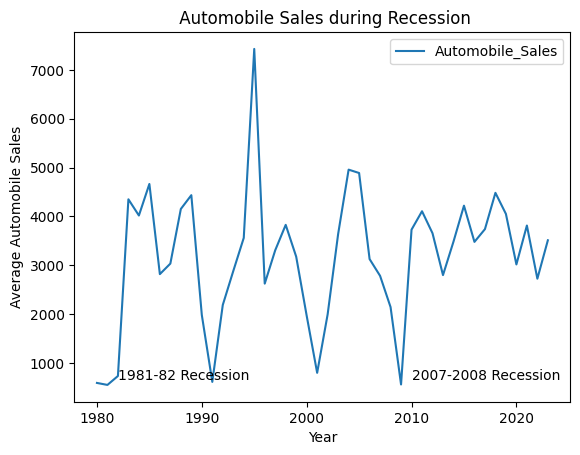

In [13]:
df_year.plot(kind = 'line',x = 'Year',y = 'Automobile_Sales')
plt.title(' Automobile Sales during Recession')
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.text(1982, 650, '1981-82 Recession')
plt.text(2010, 650, '2007-2008 Recession')
plt.show()

In [14]:
#  TASK 1.2: How do trends in advertising expenditure correlate with automobile sales during non-recession periods, and what insights can be derived from this relationship.


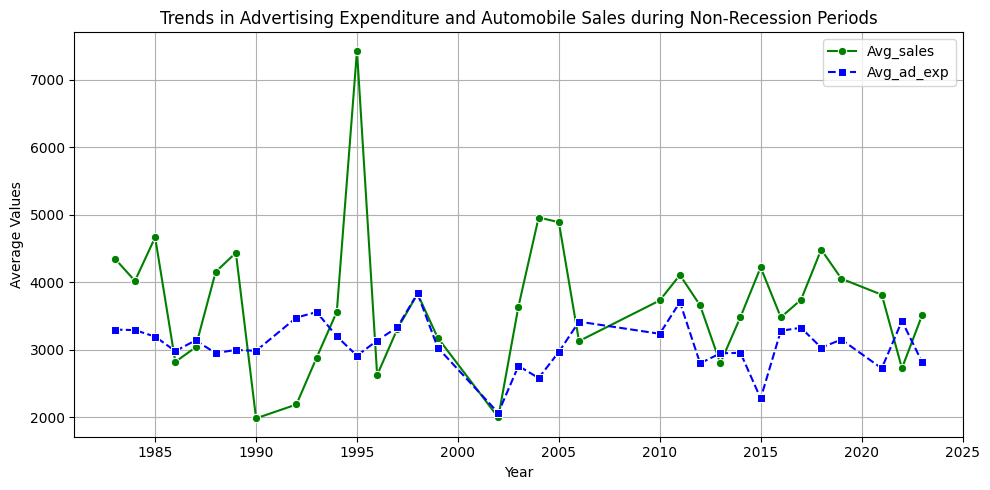

In [15]:
df_non_rec = df[df['Recession']==0]

df_trends = df_non_rec.groupby(['Year']).agg(
    Avg_sales = ('Automobile_Sales','mean'),
    Avg_ad_exp = ('Advertising_Expenditure','mean')

)


plt.figure(figsize = (10,5))
sns.lineplot(data = df_trends, x = 'Year', y = 'Avg_sales',marker = 'o',linestyle = '-',color = 'green',label = 'Avg_sales')
sns.lineplot(data=  df_trends, x = 'Year',y = 'Avg_ad_exp',marker = 's',linestyle = '--',color = 'blue',label = 'Avg_ad_exp')

plt.xlabel('Year')
plt.ylabel('Average Values')
plt.title('Trends in Advertising Expenditure and Automobile Sales during Non-Recession Periods')
plt.tight_layout()
plt.grid()
plt.show()

Inference:
The graph shows that during non-recession periods, automobile sales are more volatile than advertising expenditure. While there are moments of alignment, sales often spike independently, suggesting other factors like market demand or economic conditions also play a significant role. The correlation between advertising and sales appears inconsistent over time.

In [16]:
# TASK 1.3: Use the functionality of Seaborn Library to create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.

In [17]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

In [18]:
# TASK 1.3: Use the functionality of Seaborn Library to create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.

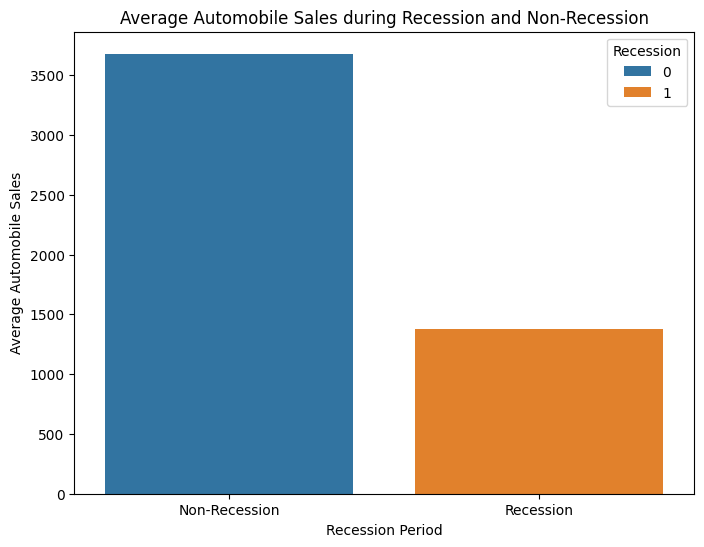

In [22]:
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

# Create the bar chart using seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession',  data=new_df)
plt.xlabel('Recession Period')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.show()

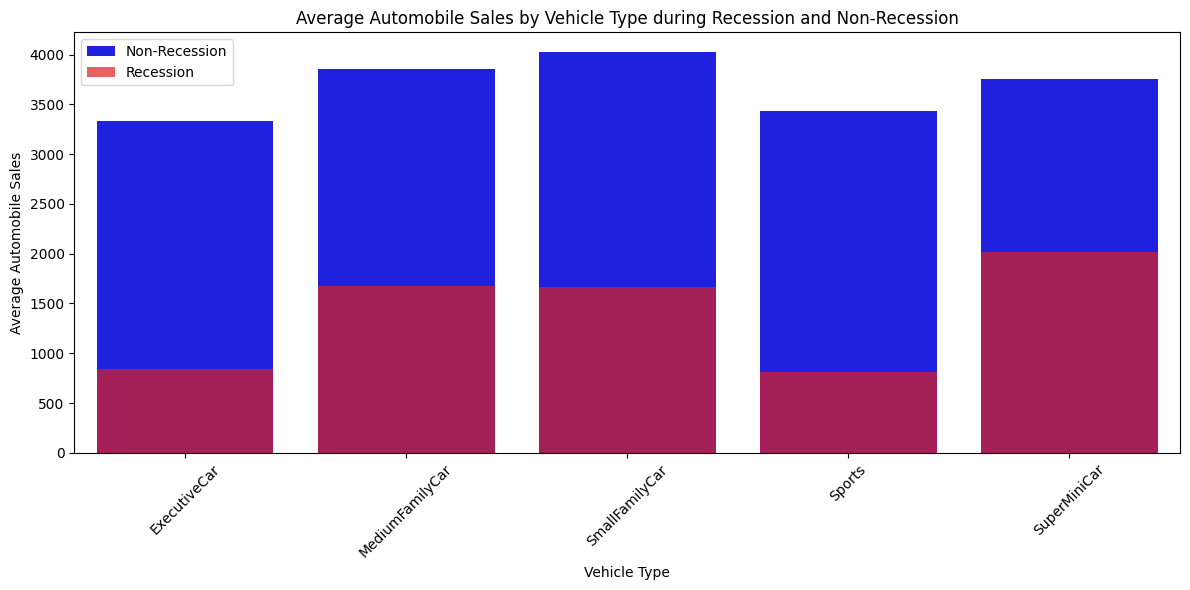

In [24]:
df_non_res = df[df['Recession'] == 0]
df_rec = df[df['Recession'] == 1]
df_non_res_grouped = df_non_res.groupby(['Vehicle_Type'])['Automobile_Sales'].mean().reset_index()
df_rec_grouped = df_rec.groupby(['Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Vehicle_Type', y='Automobile_Sales', data=df_non_res_grouped, color='blue', label='Non-Recession')
sns.barplot(x='Vehicle_Type', y='Automobile_Sales', data=df_rec_grouped, color='red', label='Recession', alpha=0.7)
plt.xlabel('Vehicle Type')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales by Vehicle Type during Recession and Non-Recession')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Inference
From this plot, we can understand that there is a drastic decline in the overall sales of the automobiles during recession.
However, the most affected type of vehicle is executivecar and sports

In [25]:
# TASK 1.4: Use sub plotting to compare the variations in GDP during recession and non-recession period by developing line plots for each period.


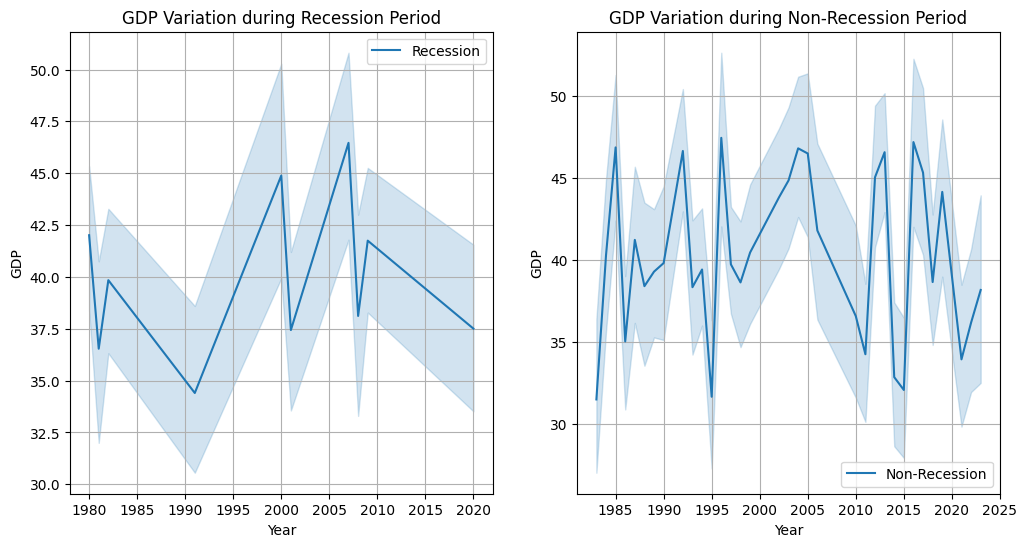

In [26]:
fig = plt.figure(figsize = (12,6))

ax0 = fig.add_subplot(1,2,1)
ax1 = fig.add_subplot(1,2,2)

sns.lineplot(data = df_rec,x = 'Year',y = 'GDP',label = 'Recession',ax = ax0)
sns.lineplot(data = df_non_res,x = 'Year',y = 'GDP',label = 'Non-Recession',ax = ax1)

ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')
ax0.grid()

ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation during Non-Recession Period')
ax1.grid()

Inference
From this plot, it is evident that GDP tends to be lower and more volatile during recessions, with significant fluctuations and uncertainty. In contrast, non-recessionary periods show a relatively higher GDP level but still exhibit some degree of variability.

In [28]:
# # 
# TASK 1.5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales.

In [29]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

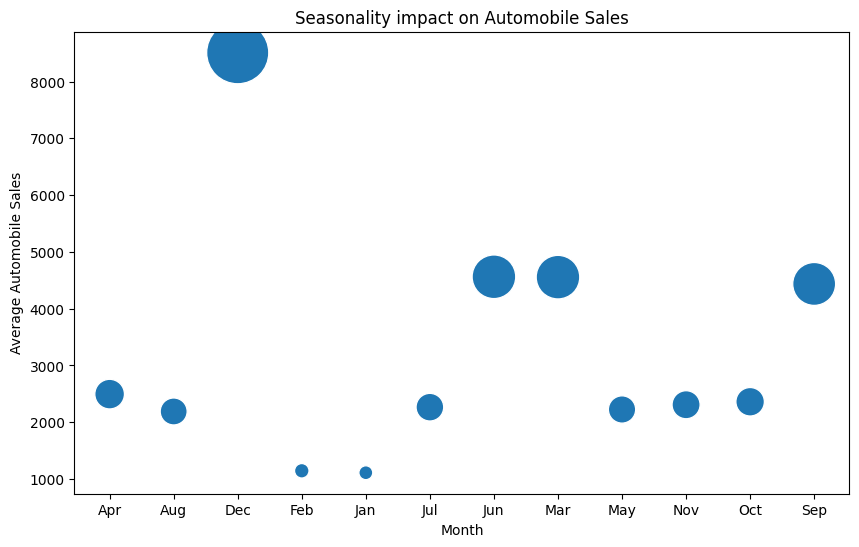

In [31]:
df_month = df.groupby('Month')['Automobile_Sales'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Month', y='Automobile_Sales', size='Automobile_Sales', data=df_month, legend=False, sizes=(100, 2000))
plt.xlabel('Month')
plt.ylabel('Average Automobile Sales')
plt.title('Seasonality impact on Automobile Sales')
plt.show()

Inference
From this plot, it is evident that seasonality has not affected on the overall sales. However, there is a drastic raise in sales in the month of April and December

In [32]:
# TASK 1.6: Use the functionality of Matplotlib to develop a scatter plot to identify the relationship between consumer confidence and automobile sales during recessions.

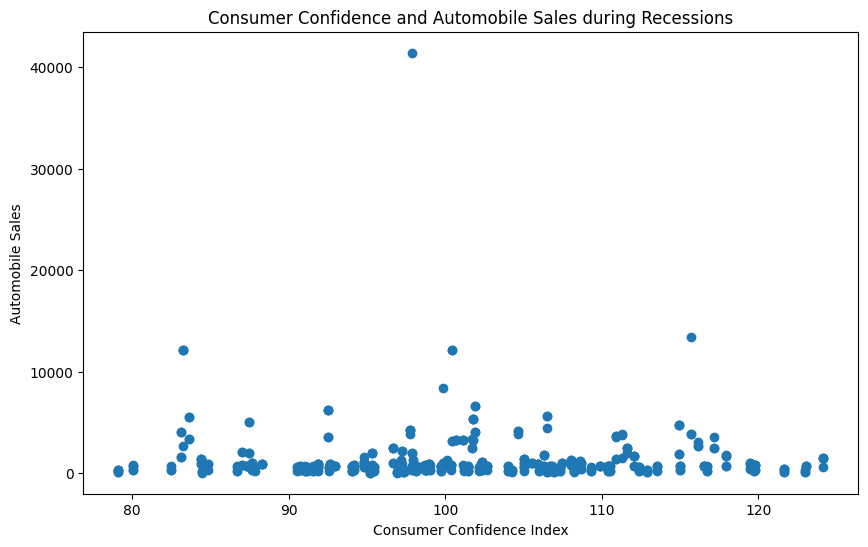

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(df_rec['Consumer_Confidence'], df_rec['Automobile_Sales'])
plt.xlabel('Consumer Confidence Index')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.show()

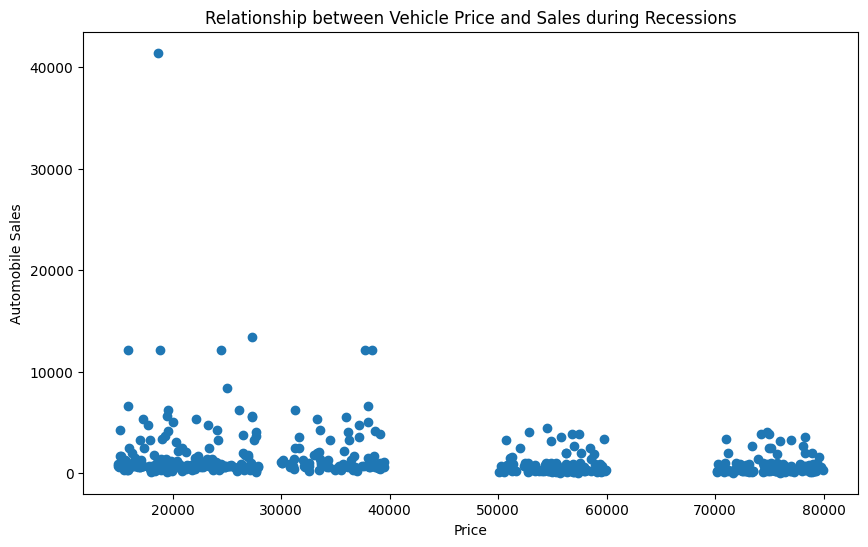

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(df_rec['Price'],df_rec['Automobile_Sales'])
plt.xlabel('Price')
plt.ylabel('Automobile Sales')  
plt.title('Relationship between Vehicle Price and Sales during Recessions')
plt.show()


Inference
The graphs indicate that during recessions, higher consumer confidence tends to boost automobile sales, while higher vehicle prices generally correspond to lower sales. This highlights the strong influence of both consumer sentiment and affordability on purchasing decisions during economic downturns.

In [39]:
# TASK 1.7: Create a pie chart to display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods.

In [40]:
df_pie = df.groupby('Recession')['Advertising_Expenditure'].sum().reset_index()
df_pie

,Recession,Advertising_Expenditure
0,0,5031103.0
1,1,1050915.6


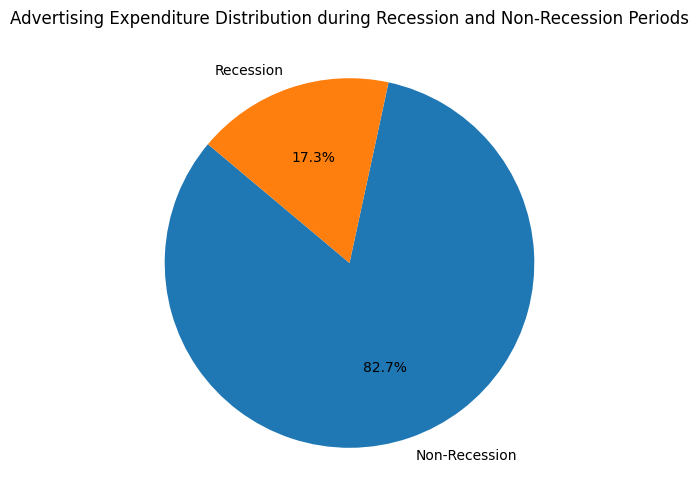

In [42]:
plt.figure(figsize=(10, 6))
labels = ['Non-Recession', 'Recession']
plt.pie(df_pie['Advertising_Expenditure'],labels=labels,autopct='%1.1f%%', startangle=140   )
plt.title('Advertising Expenditure Distribution during Recession and Non-Recession Periods')
plt.show()

In [43]:
# TASK 1.8: Develop a pie chart to display the total Advertisement expenditure for each vehicle type during recession period.

Text(0.5, 1.0, 'Advertisement Expenditure Distribution by Vehicle Type during Recession Period')

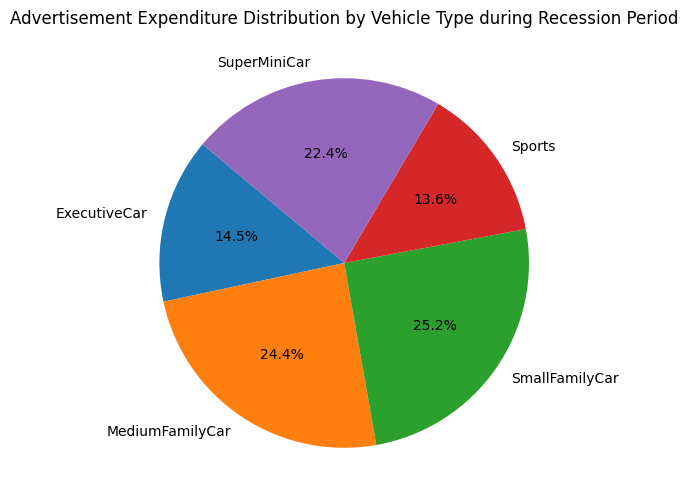

In [44]:
df_vehicle_rec = df_rec.groupby('Vehicle_Type')['Advertising_Expenditure'].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.pie(df_vehicle_rec['Advertising_Expenditure'],labels=df_vehicle_rec['Vehicle_Type'],autopct='%1.1f%%', startangle=140)
plt.title('Advertisement Expenditure Distribution by Vehicle Type during Recession Period') 

Inference
During recession the advertisements were mostly focued on low price range vehicle. A wise decision!

In [ ]:
# TASK 1.9: Develop a lineplot to analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period.

<Axes: xlabel='unemployment_rate', ylabel='Automobile_Sales'>

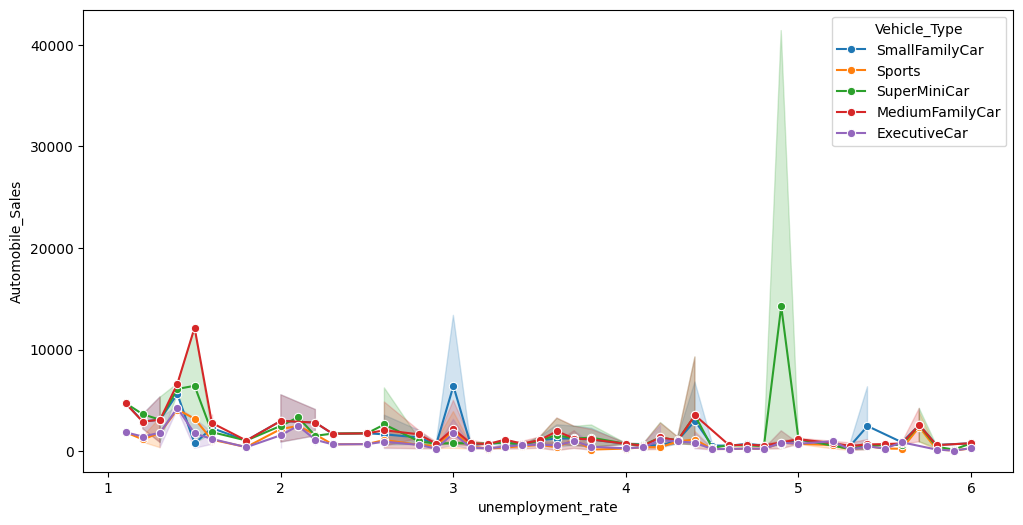

In [46]:
fig = plt.figure(figsize=(12,6))
sns.lineplot(data = df_rec,x = 'unemployment_rate',y = 'Automobile_Sales',hue = 'Vehicle_Type',marker = 'o' )
